
**Practical 02: Data Cleaning, Preprocessing and Exploratory Data Analysis**


To perform essential data cleaning, preprocessing, and exploratory analysis of a Pharmacognosy dataset using Python and Pandas in Google Colab.

Objectives

By completing this practical, the learner will be able to:

Identify and handle missing values.
Detect and remove duplicate records.
Identify and correct inappropriate data types.
Separate numerical and categorical variables.
Encode categorical variables for machine-learning applications.
Apply appropriate techniques for handling missing numerical and categorical data.
Detect and understand potential outliers.
Apply basic data transformation techniques.
Perform feature scaling and normalization.
Examine relationships between numerical variables.
Generate basic visualizations for exploratory data analysis.
Prepare a clean dataset suitable for machine-learning model development.
Learning Outcomes

After completing this practical, the learner will be able to identify common data-quality problems, clean and preprocess a Pharmacognosy dataset, transform categorical and numerical variables appropriately, detect potential outliers and relationships among variables, perform basic exploratory data analysis, and prepare a structured dataset suitable for subsequent machine-learning algorithms.


In [1]:
# Block 1: Loading and Reviewing the Master Dataset

import pandas as pd

url = "https://raw.githubusercontent.com/drpharmacy/pharma-ml-projects/main/Excel_Files/Small%20data%20set%20cognosy.xlsx"

df = pd.read_excel(url)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)

print("\nFirst 5 rows:")
display(df.head())

Dataset loaded successfully.
Shape of dataset: (100, 6)

First 5 rows:


,Plant_Name,Plant_Part,Temperature_C,Total_Phenolic_Content_mg_GAE_g,Extraction_Yield_pct,Quality_Class
0,Aloe vera,Root,67.0,25.78,17.28,Low
1,Curcuma longa,Root,76.0,49.93,23.38,Medium
2,Bacopa monnieri,Stem,78.0,110.05,24.06,Medium
3,Aloe vera,Root,58.0,132.24,23.14,Medium
4,Ocimum tenuiflorum,Root,49.0,126.05,22.39,Medium


**Meaning of Code Block 1**

This code block imports Pandas, stores the RAW GitHub location of the master Pharmacognosy Excel file in the variable url, and uses pd.read_excel() to load the Excel dataset directly into a Pandas DataFrame named df. The df.shape command confirms the number of rows and columns, while df.head() displays the first five records so that we can verify that the correct dataset has been loaded successfully. This establishes the starting point for the data-cleaning and preprocessing workflow in Practical 02.

In [3]:
# Block 2: Identifying Missing Values

print("Missing values in each column:")
print(df.isnull().sum())

print("\nPercentage of missing values in each column:")
print((df.isnull().sum() / len(df) * 100).round(2))

print("\nTotal missing values in the dataset:")
print(df.isnull().sum().sum())

Missing values in each column:
Plant_Name                         0
Plant_Part                         0
Temperature_C                      2
Total_Phenolic_Content_mg_GAE_g    2
Extraction_Yield_pct               0
Quality_Class                      0
dtype: int64

Percentage of missing values in each column:
Plant_Name                         0.0
Plant_Part                         0.0
Temperature_C                      2.0
Total_Phenolic_Content_mg_GAE_g    2.0
Extraction_Yield_pct               0.0
Quality_Class                      0.0
dtype: float64

Total missing values in the dataset:
4


**Meaning of Code Block 2**

This code block identifies missing or blank values in the dataset, which is one of the first steps in data cleaning. df.isnull().sum() counts the missing values in each column, while (df.isnull().sum() / len(df) * 100) calculates the percentage of missing values relative to the total number of records. The final df.isnull().sum().sum() gives the total number of missing cells in the entire dataset. Understanding the amount and location of missing data helps us decide the appropriate method for handling it before applying machine-learning algorithms.

In [4]:
# Block 3: Handling Missing Values

# Create a copy so that the original dataset remains unchanged
df_clean = df.copy()

# Fill missing numerical values with the median
numerical_columns = df_clean.select_dtypes(include="number").columns

for column in numerical_columns:
    df_clean[column] = df_clean[column].fillna(df_clean[column].median())

# Fill missing categorical values with the mode
categorical_columns = df_clean.select_dtypes(include="object").columns

for column in categorical_columns:
    if df_clean[column].isnull().sum() > 0:
        df_clean[column] = df_clean[column].fillna(df_clean[column].mode()[0])

# Check missing values after treatment
print("Missing values after treatment:")
print(df_clean.isnull().sum())

Missing values after treatment:
Plant_Name                         0
Plant_Part                         0
Temperature_C                      0
Total_Phenolic_Content_mg_GAE_g    0
Extraction_Yield_pct               0
Quality_Class                      0
dtype: int64


**Meaning of Code Block 3**

This code block demonstrates a practical method for handling missing values while preserving the original dataset. A copy named df_clean is created first, after which Pandas automatically identifies numerical and categorical columns using select_dtypes(). Missing numerical values are replaced with the median of their respective columns, which is generally more resistant to extreme values than the mean, while missing categorical values are replaced with the mode, meaning the most frequently occurring category. Finally, the code checks the dataset again to confirm whether missing values have been successfully handled. This creates a cleaner dataset for subsequent preprocessing and machine-learning analysis.

In [5]:
# Block 4: Detecting and Removing Duplicate Records

# Count duplicate rows
duplicate_count = df_clean.duplicated().sum()

print("Number of duplicate records:", duplicate_count)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Reset the index after removing duplicates
df_clean = df_clean.reset_index(drop=True)

print("\nShape after removing duplicates:", df_clean.shape)

# Verify that no duplicate rows remain
print("Duplicate records remaining:", df_clean.duplicated().sum())

Number of duplicate records: 0

Shape after removing duplicates: (100, 6)
Duplicate records remaining: 0


**Meaning of Code Block 4**

This code block identifies and removes duplicate records from the cleaned dataset. The duplicated().sum() command counts the number of completely duplicated rows, while drop_duplicates() removes those repeated records. After removal, reset_index(drop=True) creates a new continuous index so that the DataFrame remains properly organized. The final check confirms whether any duplicate records remain. Removing duplicates is important because repeated observations can unintentionally give certain samples greater influence during statistical analysis and machine-learning model training.

In [6]:
# Block 5: Checking and Correcting Data Types

print("Data types before correction:")
print(df_clean.dtypes)

# Convert numerical columns to numeric data type
numerical_columns = [
    "Temperature_C",
    "Total_Phenolic_Content_mg_GAE_g",
    "Extraction_Yield_pct"
]

for column in numerical_columns:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

# Convert categorical columns to string data type
categorical_columns = [
    "Plant_Name",
    "Plant_Part",
    "Quality_Class"
]

for column in categorical_columns:
    df_clean[column] = df_clean[column].astype("string")

print("\nData types after correction:")
print(df_clean.dtypes)

Data types before correction:
Plant_Name                          object
Plant_Part                          object
Temperature_C                      float64
Total_Phenolic_Content_mg_GAE_g    float64
Extraction_Yield_pct               float64
Quality_Class                       object
dtype: object

Data types after correction:
Plant_Name                         string[python]
Plant_Part                         string[python]
Temperature_C                             float64
Total_Phenolic_Content_mg_GAE_g           float64
Extraction_Yield_pct                      float64
Quality_Class                      string[python]
dtype: object


**Meaning of Code Block 5**

This code block checks and standardizes the data types of the variables in our Pharmacognosy dataset. Numerical variables such as temperature, total phenolic content, and extraction yield are converted to numeric format using pd.to_numeric(), while categorical variables such as plant name, plant part, and quality class are converted to Pandas string format using astype("string"). The errors="coerce" option converts any value that cannot be interpreted as a number into a missing value (NaN), which can subsequently be identified and treated during preprocessing. Correct data types are essential because Python and machine-learning algorithms perform different operations depending on whether a variable is numerical or categorical.

In [7]:
# Block 6: Separating Numerical and Categorical Features

# Identify numerical columns
numerical_features = df_clean.select_dtypes(include="number").columns.tolist()

# Identify categorical columns
categorical_features = df_clean.select_dtypes(include=["object", "string", "category"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

# Display the numerical variables
print("\nNumerical data:")
display(df_clean[numerical_features].head())

# Display the categorical variables
print("\nCategorical data:")
display(df_clean[categorical_features].head())

Numerical features:
['Temperature_C', 'Total_Phenolic_Content_mg_GAE_g', 'Extraction_Yield_pct']

Categorical features:
['Plant_Name', 'Plant_Part', 'Quality_Class']

Numerical data:


,Temperature_C,Total_Phenolic_Content_mg_GAE_g,Extraction_Yield_pct
0,67.0,25.78,17.28
1,76.0,49.93,23.38
2,78.0,110.05,24.06
3,58.0,132.24,23.14
4,49.0,126.05,22.39



Categorical data:


,Plant_Name,Plant_Part,Quality_Class
0,Aloe vera,Root,Low
1,Curcuma longa,Root,Medium
2,Bacopa monnieri,Stem,Medium
3,Aloe vera,Root,Medium
4,Ocimum tenuiflorum,Root,Medium


**Meaning of Code Block 6**

This code block separates the dataset variables into numerical features and categorical features, which is an important step before machine-learning preprocessing. The select_dtypes() function automatically identifies columns according to their data types, and .columns.tolist() converts the resulting column names into Python lists. Numerical variables contain measurable quantities such as temperature, phenolic content, and extraction yield, whereas categorical variables contain groups or labels such as plant name, plant part, and quality class. This separation is necessary because numerical and categorical variables generally require different preprocessing techniques before they can be supplied to machine-learning algorithms.

In [8]:
# Block 7: Encoding Categorical Variables

# Create a copy for encoding
df_encoded = df_clean.copy()

# Convert categorical feature columns into numerical dummy variables
df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Plant_Name", "Plant_Part"],
    drop_first=True,
    dtype=int
)

print("Dataset after encoding:")
display(df_encoded.head())

print("\nNew dataset shape:")
print(df_encoded.shape)

print("\nUpdated column names:")
print(df_encoded.columns.tolist())

Dataset after encoding:


,Temperature_C,Total_Phenolic_Content_mg_GAE_g,Extraction_Yield_pct,Quality_Class,Plant_Name_Azadirachta indica,Plant_Name_Bacopa monnieri,Plant_Name_Curcuma longa,Plant_Name_Gmelina arborea,Plant_Name_Moringa oleifera,Plant_Name_Ocimum tenuiflorum,Plant_Name_Withania somnifera,Plant_Part_Rhizome,Plant_Part_Root,Plant_Part_Seed,Plant_Part_Stem
0,67.0,25.78,17.28,Low,0,0,0,0,0,0,0,0,1,0,0
1,76.0,49.93,23.38,Medium,0,0,1,0,0,0,0,0,1,0,0
2,78.0,110.05,24.06,Medium,0,1,0,0,0,0,0,0,0,0,1
3,58.0,132.24,23.14,Medium,0,0,0,0,0,0,0,0,1,0,0
4,49.0,126.05,22.39,Medium,0,0,0,0,0,1,0,0,1,0,0



New dataset shape:
(100, 15)

Updated column names:
['Temperature_C', 'Total_Phenolic_Content_mg_GAE_g', 'Extraction_Yield_pct', 'Quality_Class', 'Plant_Name_Azadirachta indica', 'Plant_Name_Bacopa monnieri', 'Plant_Name_Curcuma longa', 'Plant_Name_Gmelina arborea', 'Plant_Name_Moringa oleifera', 'Plant_Name_Ocimum tenuiflorum', 'Plant_Name_Withania somnifera', 'Plant_Part_Rhizome', 'Plant_Part_Root', 'Plant_Part_Seed', 'Plant_Part_Stem']


**Meaning of Code Block 7**

This code block converts the categorical feature variables Plant_Name and Plant_Part into numerical variables using Pandas' get_dummies() function, a process known as one-hot encoding. Machine-learning algorithms generally require numerical input, so categories such as different plant species and plant parts must be represented numerically. drop_first=True removes one category from each categorical variable to avoid redundant dummy variables in models where this can create multicollinearity, while dtype=int represents the encoded categories as 0 and 1. The target variable Quality_Class is deliberately not encoded here because classification targets will be handled appropriately when we build classification models.

In [9]:
# Block 8: Detecting Outliers Using the IQR Method

# Select numerical feature columns for outlier analysis
outlier_columns = [
    "Temperature_C",
    "Total_Phenolic_Content_mg_GAE_g",
    "Extraction_Yield_pct"
]

# Calculate Q1 and Q3
Q1 = df_clean[outlier_columns].quantile(0.25)
Q3 = df_clean[outlier_columns].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Define lower and upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Count outliers in each numerical column
outlier_counts = (
    (df_clean[outlier_columns] < lower_limit) |
    (df_clean[outlier_columns] > upper_limit)
).sum()

print("Number of outliers in each numerical column:")
print(outlier_counts)

# Display the lower and upper limits
print("\nLower limits:")
print(lower_limit)

print("\nUpper limits:")
print(upper_limit)

Number of outliers in each numerical column:
Temperature_C                      0
Total_Phenolic_Content_mg_GAE_g    0
Extraction_Yield_pct               0
dtype: int64

Lower limits:
Temperature_C                      12.00000
Total_Phenolic_Content_mg_GAE_g   -26.93875
Extraction_Yield_pct                9.48625
dtype: float64

Upper limits:
Temperature_C                      100.00000
Total_Phenolic_Content_mg_GAE_g    240.23125
Extraction_Yield_pct                33.81625
dtype: float64


**Meaning of Code Block 8**

This code block detects potential outliers in the numerical variables using the Interquartile Range (IQR) method. quantile(0.25) and quantile(0.75) calculate the first quartile (Q1) and third quartile (Q3), respectively, and the IQR is calculated as Q3 − Q1. Values below Q1 − 1.5 × IQR or above Q3 + 1.5 × IQR are identified as potential outliers. The code counts the potential outliers in each numerical variable and displays the calculated lower and upper limits. Importantly, this block only detects outliers; it does not delete or alter them, because an unusual pharmacognosy observation may represent a genuine observation rather than an error.

In [10]:
# Block 9: Feature Scaling and Normalization

from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select numerical input features only
numerical_features = [
    "Temperature_C",
    "Total_Phenolic_Content_mg_GAE_g"
]

# Standardization
standard_scaler = StandardScaler()

df_scaled = df_clean.copy()

df_scaled[numerical_features] = standard_scaler.fit_transform(
    df_scaled[numerical_features]
)

print("Data after Standardization:")
display(df_scaled[numerical_features].head())

# Min-Max Normalization
minmax_scaler = MinMaxScaler()

df_normalized = df_clean.copy()

df_normalized[numerical_features] = minmax_scaler.fit_transform(
    df_normalized[numerical_features]
)

print("\nData after Min-Max Normalization:")
display(df_normalized[numerical_features].head())

Data after Standardization:


,Temperature_C,Total_Phenolic_Content_mg_GAE_g
0,0.810587,-1.892761
1,1.512731,-1.331542
2,1.668763,0.065580
3,0.108442,0.581251
4,-0.593702,0.437402



Data after Min-Max Normalization:


,Temperature_C,Total_Phenolic_Content_mg_GAE_g
0,0.744186,0.000000
1,0.953488,0.158174
2,1.000000,0.551939
3,0.534884,0.697275
4,0.325581,0.656733


**Meaning of Code Block 9**

This code block demonstrates two commonly used feature-scaling techniques: Standardization and Min-Max Normalization. StandardScaler() transforms numerical features so that they generally have a mean close to 0 and a standard deviation close to 1, whereas MinMaxScaler() transforms values to a defined range, normally 0 to 1. Only the numerical input features Temperature_C and Total_Phenolic_Content_mg_GAE_g are scaled; the target variables are deliberately left unchanged because target transformation should be handled according to the requirements of the particular machine-learning model. Feature scaling is especially important for algorithms such as KNN, SVM, and neural networks, where differences in feature magnitude can affect model performance.

Correlation matrix:


,Temperature_C,Total_Phenolic_Content_mg_GAE_g,Extraction_Yield_pct
Temperature_C,1.000000,0.058513,0.603433
Total_Phenolic_Content_mg_GAE_g,0.058513,1.000000,0.647993
Extraction_Yield_pct,0.603433,0.647993,1.000000


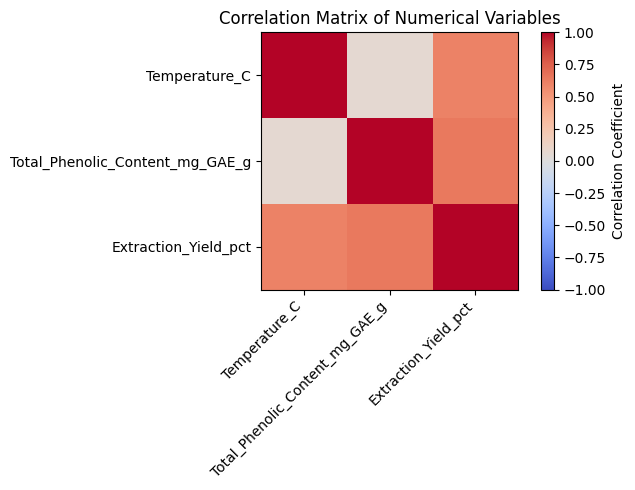

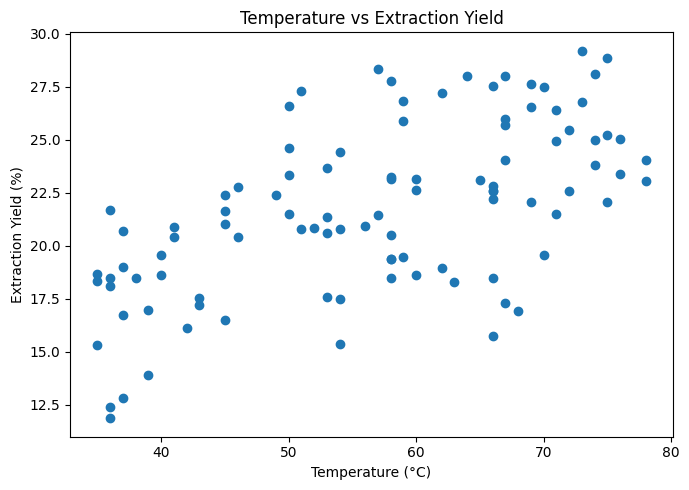

In [11]:
# Block 10: Correlation Analysis and Basic Visualization

import matplotlib.pyplot as plt

# Calculate correlation between numerical variables
correlation_matrix = df_clean[
    ["Temperature_C",
     "Total_Phenolic_Content_mg_GAE_g",
     "Extraction_Yield_pct"]
].corr()

print("Correlation matrix:")
display(correlation_matrix)

# Visualize correlations using a heatmap
plt.figure(figsize=(7, 5))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)

plt.colorbar(label="Correlation Coefficient")
plt.xticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns,
           rotation=45,
           ha="right")
plt.yticks(range(len(correlation_matrix.columns)),
           correlation_matrix.columns)

plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

# Scatter plot: Temperature vs Extraction Yield
plt.figure(figsize=(7, 5))
plt.scatter(
    df_clean["Temperature_C"],
    df_clean["Extraction_Yield_pct"]
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Extraction Yield (%)")
plt.title("Temperature vs Extraction Yield")
plt.tight_layout()
plt.show()

**Meaning of Code Block 10**

This code block examines relationships among the numerical variables using correlation analysis and visualization. The corr() function calculates the correlation coefficient between pairs of numerical variables, with values ranging from −1 to +1, where values closer to +1 indicate a positive relationship, values closer to −1 indicate a negative relationship, and values near 0 indicate a weak linear relationship. The imshow() function presents the correlation matrix visually as a heatmap, while the scatter plot shows the relationship between extraction temperature and extraction yield for individual observations. Exploratory analysis like this helps us understand patterns and relationships in the dataset before developing machine-learning models.

In [12]:
# Block 11: Final Preprocessing Check and Preparation of ML-Ready Data

# Check the cleaned dataset
print("Final shape of cleaned dataset:")
print(df_clean.shape)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate records:")
print(df_clean.duplicated().sum())

# Define features and target variables
X = df_clean[
    [
        "Plant_Name",
        "Plant_Part",
        "Temperature_C",
        "Total_Phenolic_Content_mg_GAE_g"
    ]
]

y_regression = df_clean["Extraction_Yield_pct"]

y_classification = df_clean["Quality_Class"]

print("\nFeatures (X):")
display(X.head())

print("\nRegression target:")
display(y_regression.head())

print("\nClassification target:")
display(y_classification.head())

Final shape of cleaned dataset:
(100, 6)

Missing values:
Plant_Name                         0
Plant_Part                         0
Temperature_C                      0
Total_Phenolic_Content_mg_GAE_g    0
Extraction_Yield_pct               0
Quality_Class                      0
dtype: int64

Duplicate records:
0

Features (X):


,Plant_Name,Plant_Part,Temperature_C,Total_Phenolic_Content_mg_GAE_g
0,Aloe vera,Root,67.0,25.78
1,Curcuma longa,Root,76.0,49.93
2,Bacopa monnieri,Stem,78.0,110.05
3,Aloe vera,Root,58.0,132.24
4,Ocimum tenuiflorum,Root,49.0,126.05



Regression target:


,Extraction_Yield_pct
0,17.28
1,23.38
2,24.06
3,23.14
4,22.39



Classification target:


,Quality_Class
0,Low
1,Medium
2,Medium
3,Medium
4,Medium


**Meaning of Code Block 11**

This code block performs the final quality check and prepares the dataset conceptually for machine-learning applications. It verifies the final number of records and variables, checks whether missing values or duplicate records remain, and then separates the dataset into input features (X) and two possible target variables: y_regression containing Extraction_Yield_pct for regression models and y_classification containing Quality_Class for classification models. This separation is fundamental in machine learning because the model learns the relationship between the input variables (X) and a selected target variable (y). We deliberately keep the original categorical features at this stage because encoding and model-specific preprocessing will be handled properly in the upcoming machine-learning practicals.

In [13]:
# Block 12: Saving the Cleaned Dataset

output_file = "Pharmacognosy_Cleaned_Dataset.xlsx"

df_clean.to_excel(output_file, index=False)

print("Cleaned dataset saved successfully as:", output_file)

Cleaned dataset saved successfully as: Pharmacognosy_Cleaned_Dataset.xlsx


**Meaning of Code Block 12**

This code block saves the cleaned and processed DataFrame as a new Excel file. The variable output_file defines the name of the output workbook, and df_clean.to_excel() exports df_clean to Excel while index=False prevents Pandas from adding the DataFrame index as an extra column. This allows the cleaned dataset to be preserved and reused in later analysis or machine-learning work. The original GitHub master dataset remains unchanged, which is important for reproducibility and for maintaining a reliable source dataset.

In [14]:
# Block 13: Final Dataset Summary

print("===== FINAL DATASET SUMMARY =====")

print("\nDataset shape:")
print(df_clean.shape)

print("\nColumn names:")
print(df_clean.columns.tolist())

print("\nData types:")
print(df_clean.dtypes)

print("\nMissing values:")
print(df_clean.isnull().sum())

print("\nDuplicate records:")
print(df_clean.duplicated().sum())

print("\nNumerical features:")
print(numerical_features)

print("\nRegression target:")
print("Extraction_Yield_pct")

print("\nClassification target:")
print("Quality_Class")

===== FINAL DATASET SUMMARY =====

Dataset shape:
(100, 6)

Column names:
['Plant_Name', 'Plant_Part', 'Temperature_C', 'Total_Phenolic_Content_mg_GAE_g', 'Extraction_Yield_pct', 'Quality_Class']

Data types:
Plant_Name                         string[python]
Plant_Part                         string[python]
Temperature_C                             float64
Total_Phenolic_Content_mg_GAE_g           float64
Extraction_Yield_pct                      float64
Quality_Class                      string[python]
dtype: object

Missing values:
Plant_Name                         0
Plant_Part                         0
Temperature_C                      0
Total_Phenolic_Content_mg_GAE_g    0
Extraction_Yield_pct               0
Quality_Class                      0
dtype: int64

Duplicate records:
0

Numerical features:
['Temperature_C', 'Total_Phenolic_Content_mg_GAE_g']

Regression target:
Extraction_Yield_pct

Classification target:
Quality_Class


**Meaning of Code Block 13**
**bold text**
This final code block provides a consolidated summary of the dataset after the cleaning and preprocessing operations performed in Practical 02. It confirms the dataset dimensions, available columns, data types, remaining missing values, and duplicate records, and identifies the numerical features and the two target variables that will be used later for regression and classification. This final verification acts as a quality-control checkpoint and ensures that we understand the state of the dataset before moving to the machine-learning model-building practicals.